#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

#### Useful functions/classes

In [2]:
### Takes a box and splits it into cubes (blocks) of a specified dimension. Returns
### a list of numpy arrays, each representing one block of the volume. If block_dim
### does not divide equally into the volume dimensions, creates blocks that extend past the
### dimensions of the volume, and populates the coordinates outside the volume with a chosen 
### junk, which is an input to the function
def to_blocks(box, block_dim, junk):
    
    xdim = box.shape[0]
    ydim = box.shape[1]
    zdim = box.shape[2]

    x_steps = int(xdim // block_dim)
    if xdim % block_dim != 0:
        x_steps += 1
    if xdim < block_dim:
        x_steps = 1
    y_steps = int(ydim / block_dim)
    if ydim % block_dim != 0:
        y_steps += 1
    if ydim < block_dim:
        y_steps = 1
    z_steps = int(zdim / block_dim)
    if zdim % block_dim != 0:
        z_steps += 1
    if zdim < block_dim:
        z_steps = 1
    num_blocks = int(x_steps * y_steps * z_steps)

    blocks = []

    for k in range(z_steps):
        for j in range(y_steps):
            for i in range(x_steps):

                x_lo = int(i * block_dim)
                y_lo = int(j * block_dim)
                z_lo = int(k * block_dim)

                block = np.empty((block_dim, block_dim, block_dim))

                for z in range(block_dim):
                    for y in range(block_dim):
                        for x in range(block_dim):

                            if (x_lo + x) >= xdim:
                                block[x][y][z] = junk
                            elif (y_lo + y) >= ydim:
                                block[x][y][z] = junk
                            elif (z_lo + z) >= zdim:
                                block[x][y][z] = junk
                            else:
                                block[x][y][z] = box[x_lo + x][y_lo + y][z_lo + z]
                
                blocks.append(block)

    return blocks


### Reads binary files in input_dir between timesteps min_file and max_file,
### and returns them in a list of numpy arrays, one for each chunk of data (box).
### Also returns a list of the tuples of the location and dimension of each
### box. Finally, returns a list of the number of boxes at each time step.
def process_data(input_dir, min_file, max_file, level, component):

    print("Retrieving data from directory", input_dir)
    # create output lists
    boxes = []
    locations = []
    dimensions = []
    box_counts = []

    print("Processing data...")
    for t in tqdm(range(min_file, max_file)): # iterate over each time step
        filename = input_dir + str(t) + "-wholeNewFormat-" + str(component) + "-" + str(level) + ".raw"

        # Keeps track of how many boxes are at each time step
        box_count = 0
        
        with open(filename, "rb") as file:
            while True: # Iterate through all the data at the current timestep until none is left
                test = file.read(4)
                if len(test) < 4: # Break the loop if all data has been read
                    break
                # Read the location of the box
                x = int(struct.unpack('<f', test)[0])
                y = int(struct.unpack('<f', file.read(4))[0])
                z = int(struct.unpack('<f', file.read(4))[0])
                locations.append((x, y, z))

                # Read the dimensions of the box
                xdim = int(struct.unpack('<f', file.read(4))[0])
                ydim = int(struct.unpack('<f', file.read(4))[0])
                zdim = int(struct.unpack('<f', file.read(4))[0])
                dimensions.append((xdim, ydim, zdim))

                # Read the data in the box
                box = np.empty((xdim, ydim, zdim))
                for k in range(zdim):
                    for j in range(ydim):
                        for i in range(xdim):
                            box[i][j][k] = struct.unpack('<f', file.read(4))[0]
                boxes.append(box)
                box_count += 1
                
        box_counts.append(box_count)

    return boxes, locations, dimensions, box_counts


### Assembles processed data into samples that can be used to train an autoencoder. Returns
### torch tensors with dimensions num_samples x 1 x block_dim x block_dim x block_dim; note
### that input and output are the same when training an autoencoder, so returns two instances
### of inputs
def create_samples(boxes, block_dim, junk):

    print("Creating samples...")
    
    # Check if block_dim is a power of 2 (necessary for convolutional autoencoder)
    if not math.log2(block_dim).is_integer():
        print("Invalid block_dim! Dimension must be a power of 2.")
        return
    
    inputs = []
    for i in tqdm(range(len(boxes))): # Iterate through each box (now we don't care which time step
                                      # it's associated with
        box = boxes[i]
        blocks = to_blocks(box, block_dim, junk)
        for l in range(len(blocks)): # iterate through each block and add it to the list of inputs
            input = blocks[l]
            inputs.append(input)

    inputs = np.array(inputs)
    inputs = torch.tensor(inputs, dtype=torch.float32)
    inputs = inputs[:, None, :, :, :] # add a channels dimension
    return inputs, inputs
    

class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        self.X_full = X_full
        self.y_full = y_full

    def __len__(self):
        return len(self.X_full)

    def __getitem__(self, idx):
        input = self.X_full[idx]
        output = self.y_full[idx]
        return input, output

#### Hyperparameters

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
batch_size = 256
level = 0
if level == 0:
    epochs = 1000;
else:
    epochs = 100;
component = 6
block_dim = 16
junk = 0
min_file = 74
max_file = 84
dir = "wholeVolumesNewFormat-" + str(component) + "-" + str(level) + "/"

Running on cuda


In [4]:
boxes, locations, dimensions, num_boxes = process_data(dir, min_file, max_file, level, component)
x, y = create_samples(boxes, block_dim, junk)
print(x.shape)
print(y.shape)

# Scale the data to be between 0 and 1
xmin = x.min()
xmax = x.max()
ymin = y.min()
ymax = y.max()
xnormal = (x - xmin) / (xmax - xmin)
ynormal = (y - ymin) / (ymax - ymin)

# Initialize the dataset, and create data loader
dataset = CombustionData(xnormal, ynormal)
train_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

Retrieving data from directory wholeVolumesNewFormat-6-0/
Processing data...


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.15it/s]


Creating samples...


100%|██████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:12<00:00, 413.09it/s]


torch.Size([5760, 1, 16, 16, 16])
torch.Size([5760, 1, 16, 16, 16])


#### Model initialization

In [8]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 256, kernel_size=3, stride=2, padding=1), # Output: 128 channels, block_dim/2
            nn.ReLU(),
            nn.Conv3d(256, 512, kernel_size=3, stride=2, padding=1), # Output: 256 channels, block_dim/4
            nn.ReLU(),
            nn.Conv3d(512, 1024, kernel_size=3, stride=2, padding=1), # Output: 512 channels, block_dim/8
            nn.ReLU(),
            nn.Conv3d(1024, 2048, kernel_size=3, stride=2, padding=1), # Output: 1024 channels, block_dim/16
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(2048, 1024, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 512 channels, block_dim/16
            nn.ReLU(),
            nn.ConvTranspose3d(1024, 512, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 256 channels, block_dim/8
            nn.ReLU(),
            nn.ConvTranspose3d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 128 channels, block_dim/4
            nn.ReLU(),
            nn.ConvTranspose3d(256, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: 1 channel, block_dim/2
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def decode(self, x):
        return self.decoder(x)

model = ConvAutoencoder()

#### Train model

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_hist = []

for epoch in range(epochs):
    losses = []
    for sample in train_loader:
        # Get the inputs
        inputs = sample[0]

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        _, outputs = model(inputs)

        # Compute the loss
        loss = criterion(outputs, inputs)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    # Calculate and store loss for this epoch
    epoch_loss = np.mean(losses)
    train_hist.append(epoch_loss)

    # If loss is sufficiently low, end training
    if epoch_loss < 0.00008:
        break

    # Print an update
    if epochs == 100:
        print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {epoch_loss:.8f}")
    else:
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}: Training Loss = {epoch_loss:.8f}")

print("Completed", epoch, "epochs of training, ending with a loss of", epoch_loss)

Epoch 10/1000: Training Loss = 0.00374526
Epoch 20/1000: Training Loss = 0.00276027


#### Plot loss

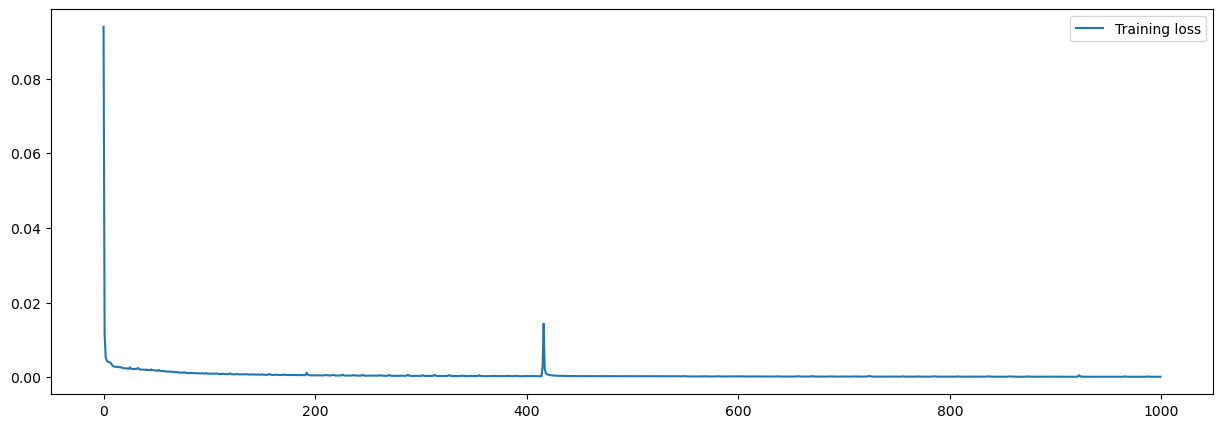

In [7]:
plt.figure(figsize=(15,5))
plt.plot(range(1000), train_hist, label='Training loss')
plt.legend()

#### Calc size of model

In [7]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 35.456MB


#### Save model

In [51]:
model_path = "testModels/model-" + str(component) + "-level" + str(level) + ".pt"
torch.save(model.state_dict(), model_path)

#### Load model

In [6]:
model_path = "testModels/model-" + str(component) + "-level" + str(level) + ".pt"
model.load_state_dict(torch.load(model_path))

/tmp/ipykernel_1147754/3778532768.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


RuntimeError: Error(s) in loading state_dict for ConvAutoencoder:
	size mismatch for encoder.0.weight: copying a param with shape torch.Size([128, 1, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([64, 1, 3, 3, 3]).
	size mismatch for encoder.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for encoder.2.weight: copying a param with shape torch.Size([256, 128, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 64, 3, 3, 3]).
	size mismatch for encoder.2.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for encoder.4.weight: copying a param with shape torch.Size([512, 256, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([256, 128, 3, 3, 3]).
	size mismatch for encoder.4.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current mod

#### Functions to encode and decode data

In [17]:
### Writes a given (usually 3d) numpy array to a binary file. For a
### 3xn array, writes in the order (1, 1), (2, 1), (3, 1), (2, 1), (2, 2),
### etc.
def write_to_bin(volume, path, out_file):
    filename = path + out_file
    with open(filename, "wb") as file:
        if len(volume.shape) == 3:
            for z in range(volume.shape[2]):
                for column in range(volume.shape[1]):
                    for row in range(volume.shape[0]):
                        packed = struct.pack("<f", volume[row, column, z])
                        file.write(packed)
        if len(volume.shape) == 2:
            for column in range(volume.shape[1]):
                for row in range(volume.shape[0]):
                    packed = struct.pack("<f", volume[row, column])
                    file.write(packed)
        if len(volume.shape) == 1:
            for row in range(volume.shape[0]):
                packed = struct.pack("<f", volume[row])
                file.write(packed)



def write_to_bin_with_loc_dim(volume, path, out_file, location, dimension):
    filename = path + out_file
    with open(filename, "wb") as file:
        # Write location
        for coord in range(len(location)):
            packed = struct.pack("<f", location[coord])
            file.write(packed)

        # Write dimension
        for coord in range(len(dimension)):
            packed = struct.pack("<f", dimension[coord])
            file.write(packed)
    
        for z in range(volume.shape[2]):
            for column in range(volume.shape[1]):
                for row in range(volume.shape[0]):
                    packed = struct.pack("<f", volume[row, column, z])
                    file.write(packed)


### Processes data, then runs it through a given encoder, and writes files to store the
### number of boxes at each time step, the location of each box, and the dimensions of each
### box, as well as the data in the boxes themselves, in a folder "encoded-lev"
def encode(encoder, input_dir, min_file, max_file, level, component, block_dim, junk):

    boxes, locations, dimensions, box_counts = process_data(input_dir, min_file, max_file, level, component)
    inputs, _ = create_samples(boxes, block_dim, junk)
    num_samples = inputs.shape[0]

    print("Inputs formatted successfully. Beginning encoding...")
    
    # Scale the data to be between 0 and 1
    input_min = inputs.min()
    input_max = inputs.max()
    input_normal = (inputs - input_min) / (input_max - input_min)
    misc = [input_min, input_max, num_samples]

    encoded, _ = encoder(input_normal)
    print("Encoding complete. Writing files...")

    dir = "encoded-" + str(level) + "/"

    write_to_bin(np.array(misc, dtype="float32"), dir, "misc.raw")
    write_to_bin(np.array(box_counts, dtype="float32"), dir, "boxCounts.raw")
    write_to_bin(np.array(locations, dtype="float32").T, dir, "locations.raw")
    write_to_bin(np.array(dimensions, dtype="float32").T, dir, "dimensions.raw")
    for b in tqdm(range(len(encoded))):
        box = encoded[b]
        box = box.cpu().detach().squeeze()
        filename = "box-" + str(b) + ".raw"
        write_to_bin(np.array(box, dtype="float32"), dir, filename)

    print("Successfully wrote files.")
    return encoded, locations, dimensions, box_counts, input_min, input_max


def read_encoded(dir, block_dim, encoded_size, timesteps):

    print("Reading encoded files...")

    with open(dir + "misc.raw", "rb") as file:
        inmin = struct.unpack("<f", file.read(4))[0]
        inmax = struct.unpack("<f", file.read(4))[0]
        num_samples = int(struct.unpack("<f", file.read(4))[0])

    box_counts = []
    with open(dir + "boxCounts.raw", "rb") as file:
        for i in range(timesteps):
            box_counts.append(int(struct.unpack("<f", file.read(4))[0]))

    locations = []
    with open(dir + "locations.raw", "rb") as file:
        for t in range(len(box_counts)):
            numBoxes = box_counts[t]
            for i in range(numBoxes):
                x = int(struct.unpack("<f", file.read(4))[0])
                y = int(struct.unpack("<f", file.read(4))[0])
                z = int(struct.unpack("<f", file.read(4))[0])
                locations.append((x, y, z))

    dimensions = []
    with open(dir + "dimensions.raw", "rb") as file:
        for t in range(len(box_counts)):
            numBoxes = box_counts[t]
            for i in range(numBoxes):
                x = int(struct.unpack("<f", file.read(4))[0])
                y = int(struct.unpack("<f", file.read(4))[0])
                z = int(struct.unpack("<f", file.read(4))[0])
                dimensions.append((x, y, z))

    coded = []
    for i in range(num_samples):
        filename = dir + "box-" + str(i) + ".raw"
        with open(filename, "rb") as file:
            
            block = np.empty((encoded_size))

            for j in range(encoded_size):
                block[j] = struct.unpack("<f", file.read(4))[0]

            coded.append(block)
    
    coded = np.array(coded)
    coded = torch.tensor(coded, dtype=torch.float32)
    coded = coded[:, :, None, None, None]

    print("Finished reading files. Ready to decode...")
    return coded, inmin, inmax, locations, dimensions, box_counts


### Decodes encoded data using a given model, then returns the decoded data
def decode(decoder, coded, inmin, inmax, locations, dimensions, block_dim, box_counts):

    num_boxes = len(locations)
    block_idx = 0
    print(len(locations), len(dimensions), len(coded))

    regenerated = []

    print("Beginning decoding...")
    for n in tqdm(range(num_boxes)):

        dims = dimensions[n]
        xdim, ydim, zdim = dims[0], dims[1], dims[2]

        generated = np.empty((xdim, ydim, zdim))
        
        x_steps = int(xdim // block_dim)
        if xdim % block_dim != 0:
            x_steps += 1
        y_steps = int(ydim // block_dim)
        if ydim % block_dim != 0:
            y_steps += 1
        z_steps = int(zdim // block_dim)
        if zdim % block_dim != 0:
            z_steps += 1

        for k in range(z_steps):
            for j in range(y_steps):
                for i in range(x_steps):

                    x_lo = int(i * block_dim)
                    y_lo = int(j * block_dim)
                    z_lo = int(k * block_dim)

                    block = coded[block_idx]
                    decoded = decoder.decode(block)
                    decoded = decoded * (inmax - inmin) + inmin
                    decoded = decoded.cpu().detach().squeeze()

                    for z in range(block_dim):
                        for y in range(block_dim):
                            for x in range(block_dim):
                                if (x_lo + x) < xdim and (y_lo + y) < ydim and (z_lo + z) < zdim:
                                    generated[x_lo + x][y_lo + y][z_lo + z] = decoded[x][y][z]

                    block_idx += 1

        regenerated.append(generated)

    print("Decoding completed successfully.")

    print("Writing decoded files...")
    box_idx = 0
    
    for t in range(len(box_counts)):
        num_boxes = box_counts[t]
        print("Writing decoded boxes for time step", str(t))
        for i in tqdm(range(num_boxes)):
            box = regenerated[box_idx]
            loc = locations[box_idx]
            dim = dimensions[box_idx]
            box = np.array(box, dtype="float32")
            #print(box.shape)
            path = "decoded-" + str(level) + "/"
            filename = "decodedBox-" + str(t) + "-" + str(i) + ".raw"
            write_to_bin_with_loc_dim(box, path, filename, loc, dim)
            box_idx += 1

    return regenerated


def calc_avg_rmse(actuals, regens):

    rmses = []
    
    for s in range(len(actuals)):

        actual = actuals[s]
        pred = regens[s]
        
        xdim = actual.shape[0]
        ydim = actual.shape[1]
        zdim = actual.shape[2]

        sum = 0
        
        for k in range(zdim):
            for j in range(ydim):
                for i in range(xdim):
                    sq = (actual[i][j][k] - pred[i][j][k])**2
                    sum += sq

        rmse = (sum / (xdim * ydim * zdim))**0.5
        rmses.append(rmse)

    rmses = np.array(rmses)
    return rmses.mean()

#### Encode, decode, and check RMSE

In [ ]:
encoded, locations, dimensions, box_counts, input_min, input_max = encode(model, dir, min_file, max_file, 
                                                                          level, component, block_dim, junk)
encoded_dir = "encoded-" + str(level) + "/"
encoded, inmin, inmax, locations, dimensions, box_counts = read_encoded(encoded_dir, block_dim, 512, max_file-min_file)
regenerated = decode(model, encoded, inmin, inmax, locations, dimensions, block_dim, box_counts)
rmse = calc_avg_rmse(boxes, regenerated)
print(rmse)

Retrieving data from directory wholeVolumesNewFormat-6-0/
Processing data...


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.14it/s]


Creating samples...


100%|██████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:12<00:00, 422.58it/s]


Inputs formatted successfully. Beginning encoding...
Encoding complete. Writing files...


...

100%|████████████████████████████████████████████████████████████████████████████████| 576/576 [00:01<00:00, 431.63it/s]


Writing decoded boxes for time step 7


100%|████████████████████████████████████████████████████████████████████████████████| 576/576 [00:01<00:00, 455.20it/s]


Writing decoded boxes for time step 8


 10%|███████▉                                                                         | 28/288 [00:00<00:00, 277.71it/s]